### Ejercicios de 4.8 - 4.10 y 4.15 - 4.16

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

4.8 - ¿La cantidad de actores influye en los ingresos de las películas? ¿Se han hecho películas con más actores en los últimos años?

Total de películas: 19883
Películas con ingresos: 5398

Correlacion: Cantidad Actores vs Ingresos
Pearson: 0.3572

Ingresos promedio por cantidad de actores:
             Películas  Promedio_M
cat_actores                       
1-5                119        4.64
6-10               303       46.27
11-20             1206       47.03
20+               3761      133.12


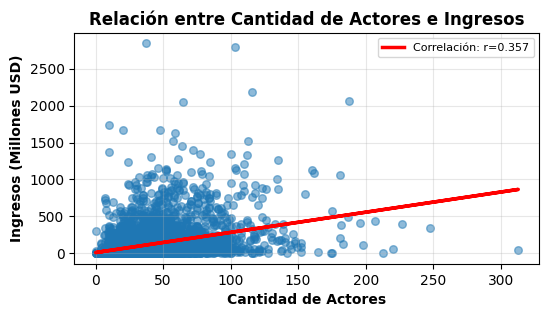

In [33]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin1')

# Filtrar películas con datos financieros (revenue > 0)
df_revenue = df[df['revenue'] > 0].copy()
print(f"Total de películas: {len(df)}")
print(f"Películas con ingresos: {len(df_revenue)}")

# Limpiar los outliers extremos de cantidad de actores para mejor visualizacion
df = df_revenue[df_revenue['actorsAmount'] < 1000].copy()

corr, p_value = stats.pearsonr(df['actorsAmount'], df['revenue'])
print("\nCorrelacion: Cantidad Actores vs Ingresos")
print(f"Pearson: {corr:.4f}")

# Dividir por cantidad de actores
df['cat_actores'] = pd.cut(df['actorsAmount'], bins=[0, 5, 10, 20, 500], labels=['1-5', '6-10', '11-20', '20+'])

print("\nIngresos promedio por cantidad de actores:")
stats_cat = df.groupby('cat_actores')['revenue'].agg([
    ('Películas', 'count'),
    ('Promedio_M', lambda x: x.mean()/1e6),
])
print(stats_cat.round(2))

# Gráfico de dispersión
plt.figure(figsize=(6, 3))
plt.scatter(df['actorsAmount'], df['revenue']/1e6, alpha=0.5, s=30)

# Línea de tendencia
z = np.polyfit(df['actorsAmount'], df['revenue']/1e6, 1)
p = np.poly1d(z)
plt.plot(df['actorsAmount'], p(df['actorsAmount']), 
         "r-", linewidth=2.5, label=f'Correlación: r={corr:.3f}')

plt.xlabel('Cantidad de Actores', fontweight='semibold', fontsize=10)
plt.ylabel('Ingresos (Millones USD)', fontweight='semibold', fontsize=10)
plt.title('Relación entre Cantidad de Actores e Ingresos', fontweight='bold', fontsize=12)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

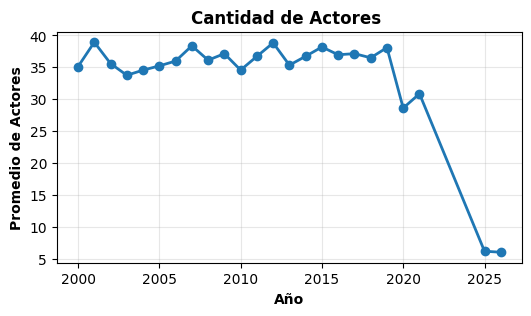

In [6]:
# ¿Más actores en últimos años?
tendencia = df.groupby('releaseYear')['actorsAmount'].mean().reset_index()
tendencia = tendencia[tendencia['releaseYear'] >= 2000]  # Solo años recientes

# Gráfico simple
plt.figure(figsize=(6, 3))
plt.plot(tendencia['releaseYear'], tendencia['actorsAmount'], marker='o', linewidth=2)
plt.xlabel('Año', fontweight='semibold')
plt.ylabel('Promedio de Actores', fontweight='semibold')
plt.title('Cantidad de Actores ', fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

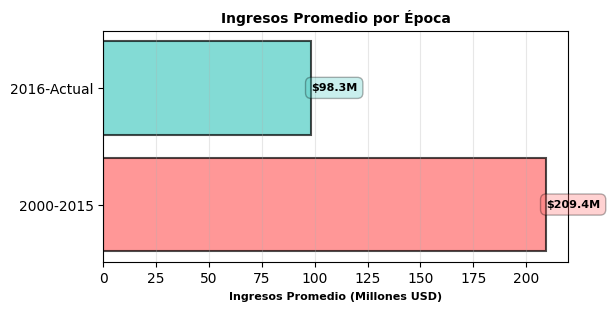

In [37]:
df_revenue = df[df['revenue'] > 0].copy()

#Filtrar por epocas y para que sea una comparacion justa se agarra la misma cantidad de peliculas con los mejores revenues
df_2000_2015 = df_revenue[(df_revenue['releaseYear'] >= 2000) & (df_revenue['releaseYear'] <= 2015)].nlargest(1451, 'revenue')
df_2016_actual = df_revenue[(df_revenue['releaseYear'] >= 2016)].nlargest(1451, 'revenue')


epochs = ['2000-2015', '2016-Actual']
data_2000 = df_2000_2015['revenue'].mean()/1e6
data_2016 = df_2016_actual['revenue'].mean()/1e6

fig, ax = plt.subplots(figsize=(6, 3))

ingresos = [data_2000, data_2016]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.barh(epochs, ingresos, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Ingresos Promedio (Millones USD)', fontweight='bold', fontsize=8)
ax.set_title('Ingresos Promedio por Época', fontweight='bold', fontsize=10)
ax.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, ingresos)):
    ax.text(val, bar.get_y() + bar.get_height()/2.,
           f'${val:.1f}M', ha='left', va='center', fontweight='bold', fontsize=8,
           bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i], alpha=0.3))

plt.show()

4.9 - ¿Es posible que la cantidad de hombres y mujeres en el reparto influya en la popularidad y los ingresos de las películas? 

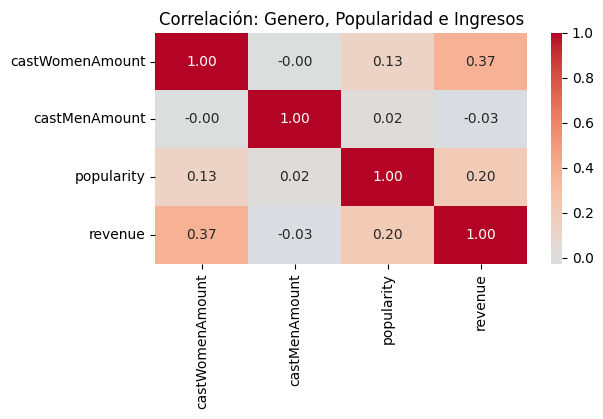

In [13]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin1')
cols = ['castWomenAmount', 'castMenAmount', 'popularity', 'revenue']
df_clean = df[cols].dropna()

# 2. Cálculo de la matriz de correlación (Pearson)
corr_matrix = df_clean.corr()

# 3. Creación del Mapa de Calor
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)

plt.title('Correlación: Genero, Popularidad e Ingresos')
plt.show()

4.10 - ¿Quiénes son los directores que hicieron las 20 películas mejor 
calificadas?

In [44]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

top_20_directores = (
    df.groupby('director')['voteAvg']
      .mean()
      .sort_values(ascending=False)
      .head(20)
      .reset_index()
)

print("TOP DIRECTORES")

for idx, director in enumerate(top_20_directores['director'], 1):
    movies = df[df['director'] == director][['title', 'voteAvg', 'releaseYear', 'revenue', 'budget']].sort_values('releaseYear')
    is_emergent = 'Sí' if movies['releaseYear'].min() >= 2020 else 'No (antes 2020)'
    
    print(f"\n{idx}. {director}")
    print(f"¿Emergente?: {is_emergent}")

TOP DIRECTORES

1. Jackson Driver
¿Emergente?: Sí

2. Aarish Ahmed|Zayne Wint
¿Emergente?: Sí

3. ADRIAN PERERA
¿Emergente?: Sí

4. Scout Georgas
¿Emergente?: Sí

5. Scott Leeker
¿Emergente?: Sí

6. Selena MarÃ­a Ortiz
¿Emergente?: Sí

7. Scarlett J. Stribley
¿Emergente?: Sí

8. Savannah Tuesday
¿Emergente?: Sí

9. James Osborn|Audrey Robinson
¿Emergente?: Sí

10. nawaf almutairi
¿Emergente?: Sí

11. Felix Baughan
¿Emergente?: Sí

12. Umay Melek Aymutlu
¿Emergente?: Sí

13. Filip Stojiljkovic
¿Emergente?: Sí

14. Ved
¿Emergente?: Sí

15. Fernando Teixeira Florencio
¿Emergente?: Sí

16. Ferliana Putri Arya Anindita
¿Emergente?: Sí

17. Fernanda Neu
¿Emergente?: Sí

18. Kurtis Spralja|Thomas Livingstone|Kai Dutch
¿Emergente?: Sí

19. Kyan McDonald
¿Emergente?: Sí

20. Kyle Christian
¿Emergente?: Sí


4.15 - ¿Qué estrategias de marketing, como videos promocionales o páginas 
oficiales, generan mejores resultados? 

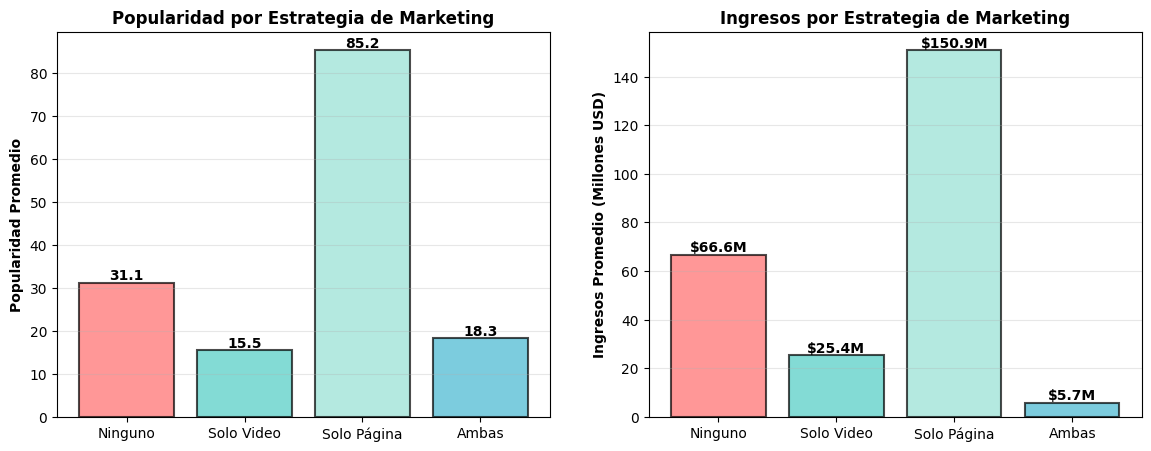

In [24]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df_analisis = df[(df['revenue'] > 0) & (df['popularity'] > 0)].copy()

df_analisis['has_video'] = df_analisis['video'].fillna(False).astype(bool)
df_analisis['has_homepage'] = df_analisis['homePage'].notna() & (df_analisis['homePage'] != '')

df_analisis['marketing_cat'] = 'Ninguno'
df_analisis.loc[df_analisis['has_video'] & ~df_analisis['has_homepage'], 'marketing_cat'] = 'Solo Video'
df_analisis.loc[~df_analisis['has_video'] & df_analisis['has_homepage'], 'marketing_cat'] = 'Solo Página'
df_analisis.loc[df_analisis['has_video'] & df_analisis['has_homepage'], 'marketing_cat'] = 'Ambas'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Ninguno', 'Solo Video', 'Solo Página', 'Ambas']
pop_data = [df_analisis[df_analisis['marketing_cat'] == cat]['popularity'].mean() for cat in categories]
rev_data = [(df_analisis[df_analisis['marketing_cat'] == cat]['revenue'].mean() / 1e6) for cat in categories]

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#45B7D1']

bars1 = axes[0].bar(categories, pop_data, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Popularidad Promedio', fontweight='bold')
axes[0].set_title('Popularidad por Estrategia de Marketing', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, pop_data):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(categories, rev_data, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Ingresos Promedio (Millones USD)', fontweight='bold')
axes[1].set_title('Ingresos por Estrategia de Marketing', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, rev_data):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'${val:.1f}M', ha='center', va='bottom', fontweight='bold')


plt.show()

4.16 - ¿La popularidad del elenco está directamente correlacionada con el éxito de taquilla?


Correlación de Pearson: 1.0000
p-value: 1.337e-05


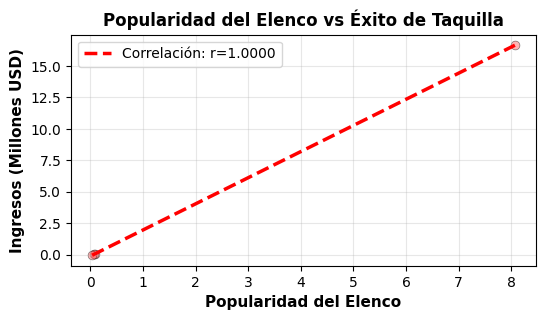

In [ ]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df['actorsPopularity'] = pd.to_numeric(df['actorsPopularity'], errors='coerce')

df_analisis = df[(df['revenue'] > 0) & (df['actorsPopularity'].notna()) & (df['actorsPopularity'] != 0)].copy()

if len(df_analisis) > 2:
    corr, p_value = stats.pearsonr(df_analisis['actorsPopularity'], df_analisis['revenue'])
else:
    corr, p_value = np.nan, np.nan

print(f"\nCorrelación de Pearson: {corr:.4f}")
print(f"p-value: {p_value:.3e}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(df_analisis['actorsPopularity'], df_analisis['revenue']/1e6, alpha=0.5, s=40, color='#FF6B6B', edgecolor='black', linewidth=0.5)
z = np.polyfit(df_analisis['actorsPopularity'], df_analisis['revenue']/1e6, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df_analisis['actorsPopularity'].min(), df_analisis['actorsPopularity'].max(), 100)
ax.plot(x_line, p_fit(x_line), "r--", linewidth=2.5, label=f'Correlación: r={corr:.4f}')

ax.set_xlabel('Popularidad del Elenco', fontweight='bold', fontsize=11)
ax.set_ylabel('Ingresos (Millones USD)', fontweight='bold', fontsize=11)
ax.set_title('Popularidad del Elenco vs Éxito de Taquilla', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.show()

## Preguntas extra

1. Relación entre Duración y Retención del Público: 
¿Afecta el runtime (duración) a la cantidad de votos recibidos?


Correlación de Pearson: 0.2768
p-value: 2.691e-193
Significancia: Si (p<0.05)


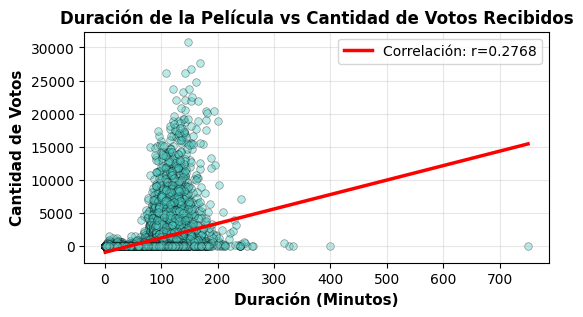

In [60]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df_analisis = df[(df['runtime'] > 0) & (df['voteCount'] > 0)].copy()

corr, p_value = stats.pearsonr(df_analisis['runtime'], df_analisis['voteCount'])

print(f"\nCorrelación de Pearson: {corr:.4f}")
print(f"p-value: {p_value:.3e}")
print(f"Significancia: {'Si (p<0.05)' if p_value < 0.05 else 'No (p≥0.05)'}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(df_analisis['runtime'], df_analisis['voteCount'], alpha=0.4, s=30, color='#4ECDC4', edgecolor='black', linewidth=0.5)

z = np.polyfit(df_analisis['runtime'], df_analisis['voteCount'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df_analisis['runtime'].min(), df_analisis['runtime'].max(), 100)
ax.plot(x_line, p_fit(x_line), "r-", linewidth=2.5, label=f'Correlación: r={corr:.4f}')

ax.set_xlabel('Duración (Minutos)', fontweight='bold', fontsize=11)
ax.set_ylabel('Cantidad de Votos', fontweight='bold', fontsize=11)
ax.set_title('Duración de la Película vs Cantidad de Votos Recibidos', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.show()

2. ¿Las películas producidas por más de un país (productionCountriesAmount > 1) tienen mayor alcance de popularidad que las de un solo país?

Producciones locales: 12,392
Co-producciones internacionales: 6,784

Produccion local                                  
  Media: 29.88

CO-produccion internacional                       
  Media: 22.35


C:\Users\irisa\AppData\Local\Temp\ipykernel_25052\2130407869.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box,


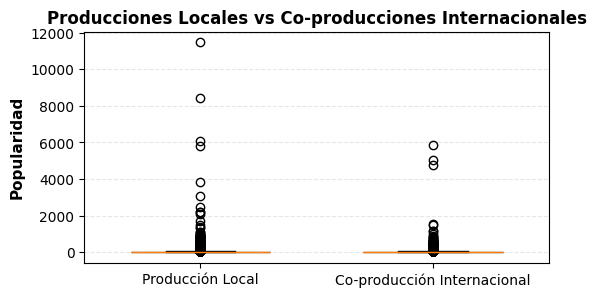

In [67]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df_analisis = df[df['popularity'] > 0].copy()

df_analisis['prod_type'] = df_analisis['productionCountriesAmount'].apply(
    lambda x: 'Producción Local' if x == 1 else 'Co-producción Internacional'
)

local = df_analisis[df_analisis['prod_type'] == 'Producción Local']['popularity']
internacional = df_analisis[df_analisis['prod_type'] == 'Co-producción Internacional']['popularity']

print(f"Producciones locales: {len(local):,}")
print(f"Co-producciones internacionales: {len(internacional):,}")

print(f"\n{'Produccion local':<50}")
print(f"  Media: {local.mean():.2f}")

print(f"\n{'CO-produccion internacional':<50}")
print(f"  Media: {internacional.mean():.2f}")

fig, ax = plt.subplots(figsize=(6, 3))

data_box = [local, internacional]
bp = ax.boxplot(data_box, 
                 labels=['Producción Local', 'Co-producción Internacional'],
                 patch_artist=True,
                 notch=False,
                 widths=0.6)

colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Popularidad', fontweight='bold', fontsize=11)
ax.set_title('Producciones Locales vs Co-producciones Internacionales', 
             fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()

3. ¿Ha cambiado la duración promedio de las películas exitosas a lo largo de los años?


Total películas exitosas analizadas: 4,113

Año      Runtime Prom    Películas    Ingresos Prom (M)   
----------------------------------------------------------------------------------------------------
2000     107.9           98           $108.75             
2001     109.4           119          $109.44             
2002     105.2           135          $113.63             
2003     107.7           131          $120.81             
2004     107.0           145          $120.49             
2005     108.2           154          $108.21             
2006     107.8           177          $97.69              
2007     107.6           164          $119.45             
2008     104.8           174          $118.22             
2009     107.4           193          $122.58             
2010     105.8           185          $125.31             
2011     106.5           190          $127.33             
2012     105.6           180          $139.53             
2013     107.8           226

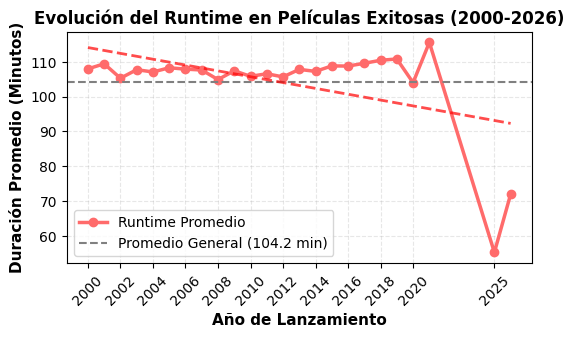

In [70]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df_exitosas = df[(df['revenue'] > 0) & (df['runtime'] > 0) & (df['releaseYear'] >= 2000)].copy()

runtime_por_ano = df_exitosas.groupby('releaseYear').agg({
    'runtime': ['mean', 'median', 'count'],
    'revenue': 'mean'
}).round(2)

runtime_por_ano.columns = ['Runtime_Promedio', 'Runtime_Mediana', 'Cantidad_Peliculas', 'Ingresos_Promedio']
runtime_por_ano = runtime_por_ano.reset_index()


print(f"\nTotal películas exitosas analizadas: {len(df_exitosas):,}")

print(f"\n{'Año':<8} {'Runtime Prom':<15} {'Películas':<12} {'Ingresos Prom (M)':<20}")
print("-"*100)
for _, row in runtime_por_ano.iterrows():
    print(f"{int(row['releaseYear']):<8} {row['Runtime_Promedio']:<15.1f} {int(row['Cantidad_Peliculas']):<12} ${row['Ingresos_Promedio']/1e6:<19.2f}")

anos = runtime_por_ano['releaseYear'].values
runtimes = runtime_por_ano['Runtime_Promedio'].values

corr, p_value = stats.pearsonr(anos, runtimes)

print(f"Correlación entre Año y Runtime Promedio: {corr:.4f}")
print(f"p-value: {p_value:.3e}")
print(f"Tendencia: {'Películas se están ACORTANDO' if corr < -0.1 else 'Películas se están ALARGANDO' if corr > 0.1 else 'Duración ESTABLE'}")


fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(anos, runtimes, marker='o', linewidth=2.5, markersize=6, color='#FF6B6B', label='Runtime Promedio')
ax.axhline(y=runtimes.mean(), color='gray', linestyle='--', linewidth=1.5, label=f'Promedio General ({runtimes.mean():.1f} min)')

ax.set_xlabel('Año de Lanzamiento', fontweight='bold', fontsize=11)
ax.set_ylabel('Duración Promedio (Minutos)', fontweight='bold', fontsize=11)
ax.set_title('Evolución del Runtime en Películas Exitosas (2000-2026)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

z = np.polyfit(anos, runtimes, 1)
p_fit = np.poly1d(z)
ax.plot(anos, p_fit(anos), "r--", linewidth=2, alpha=0.7, label=f'Tendencia Lineal (pendiente={z[0]:.2f})')

plt.xticks(anos[::2], rotation=45)
plt.show()

4. ¿Qué tan rentable es producir en idiomas distintos al inglés? ¿Cuál es el ROI (Retorno de Inversión) promedio comparando películas en inglés (en) vs. otros idiomas originales?


Total películas analizadas: 4,502
Idiomas únicos: 32

Idioma     ROI %        Películas    Presupuesto ($M)   Ingresos ($M)  
--------------------------------------------------------------------------------------------------------------
cn         2031.7       21           $24.26             $54.63         
hi         1169.0       16           $9.84              $56.12         
en         984.3        4073         $42.11             $132.29        
it         731.8        18           $9.21              $27.49         
ar         727.2        2            $2.00              $32.49         
zh         717.7        31           $33.05             $194.74        
ko         681.4        39           $10.87             $51.89         
sv         647.7        5            $6.00              $46.37         
ja         546.7        53           $13.55             $54.59         
de         523.8        15           $5.50              $33.50         
th         521.6        4            $3.90

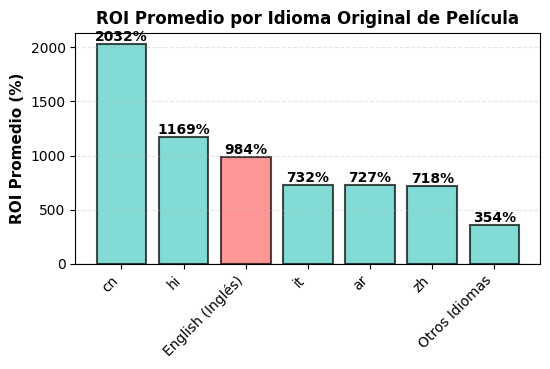

In [72]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df_rentabilidad = df[(df['revenue'] > 0) & (df['budget'] > 0)].copy()

df_rentabilidad['ROI'] = ((df_rentabilidad['revenue'] - df_rentabilidad['budget']) / df_rentabilidad['budget']) * 100

roi_por_idioma = df_rentabilidad.groupby('originalLanguage').agg({
    'ROI': ['mean', 'median', 'count'],
    'revenue': 'mean',
    'budget': 'mean'
}).round(2)

roi_por_idioma.columns = ['ROI_Promedio', 'ROI_Mediana', 'Cantidad_Peliculas', 'Ingresos_Promedio', 'Presupuesto_Promedio']
roi_por_idioma = roi_por_idioma.reset_index()
roi_por_idioma = roi_por_idioma.sort_values('ROI_Promedio', ascending=False)


print(f"\nTotal películas analizadas: {len(df_rentabilidad):,}")
print(f"Idiomas únicos: {df_rentabilidad['originalLanguage'].nunique()}")

print(f"\n{'Idioma':<10} {'ROI %':<12} {'Películas':<12} {'Presupuesto ($M)':<18} {'Ingresos ($M)':<15}")
print("-"*110)
for _, row in roi_por_idioma.iterrows():
    idioma = str(row['originalLanguage'])[:10]
    print(f"{idioma:<10} {row['ROI_Promedio']:<12.1f} {int(row['Cantidad_Peliculas']):<12} ${row['Presupuesto_Promedio']/1e6:<17.2f} ${row['Ingresos_Promedio']/1e6:<14.2f}")

print(f"\n{'='*110}")

ingles = roi_por_idioma[roi_por_idioma['originalLanguage'] == 'en']
otros = roi_por_idioma[roi_por_idioma['originalLanguage'] != 'en']

if len(ingles) > 0:
    roi_ingles = ingles['ROI_Promedio'].values[0]
    print(f"\nENGLISH (Inglés):")
    print(f"  ROI Promedio: {roi_ingles:.1f}%")
    print(f"  Películas: {int(ingles['Cantidad_Peliculas'].values[0]):,}")

print(f"\nOTROS IDIOMAS (Top 5 + Agregado):")
top5_otros = roi_por_idioma[(roi_por_idioma['originalLanguage'] != 'en')].head(5)
for _, row in top5_otros.iterrows():
    idioma = str(row['originalLanguage'])[:10]
    print(f"  {idioma}: {row['ROI_Promedio']:.1f}% ({int(row['Cantidad_Peliculas'])} películas)")

roi_otros_promedio = otros['ROI_Promedio'].mean()
print(f"\n  Promedio TODOS otros idiomas: {roi_otros_promedio:.1f}%")

print(f"\n{'='*110}")

top_idiomas = roi_por_idioma.head(6)
otros_agrupados = pd.DataFrame({
    'originalLanguage': ['Otros'],
    'ROI_Promedio': [roi_otros_promedio],
    'Cantidad_Peliculas': [otros['Cantidad_Peliculas'].sum()]
})

datos_grafico = pd.concat([top_idiomas[['originalLanguage', 'ROI_Promedio']], otros_agrupados], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 3))

idiomas_labels = []
for idioma in datos_grafico['originalLanguage']:
    if idioma == 'en':
        idiomas_labels.append('English (Inglés)')
    elif idioma == 'Otros':
        idiomas_labels.append('Otros Idiomas')
    else:
        idiomas_labels.append(idioma)

colors = ['#FF6B6B' if idioma == 'English (Inglés)' else '#4ECDC4' for idioma in idiomas_labels]

bars = ax.bar(range(len(idiomas_labels)), datos_grafico['ROI_Promedio'], color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(idiomas_labels)))
ax.set_xticklabels(idiomas_labels, rotation=45, ha='right')
ax.set_ylabel('ROI Promedio (%)', fontweight='bold', fontsize=11)
ax.set_title('ROI Promedio por Idioma Original de Película', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

for bar, val in zip(bars, datos_grafico['ROI_Promedio']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
           f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)


plt.show()

5. ¿Existe una relación entre el presupuesto invertido y la calificación promedio (voteAvg) que reciben las películas? ¿O el presupuesto alto no garantiza mejor recepción crítica?


Correlación entre Presupuesto y Calificación Promedio:
  Pearson r: 0.0497

Categoría            Películas    Presupuesto        Calif. Media    Calif. Mediana 
------------------------------------------------------------------------------------------
Bajo (<$10M)         1728         $4.6              M 6.53            6.60           
Medio ($10-50M)      2335         $26.3             M 6.50            6.50           
Alto ($50-150M)      951          $86.9             M 6.51            6.50           
Mega (>$150M)        174          $198.2            M 6.89            6.90           


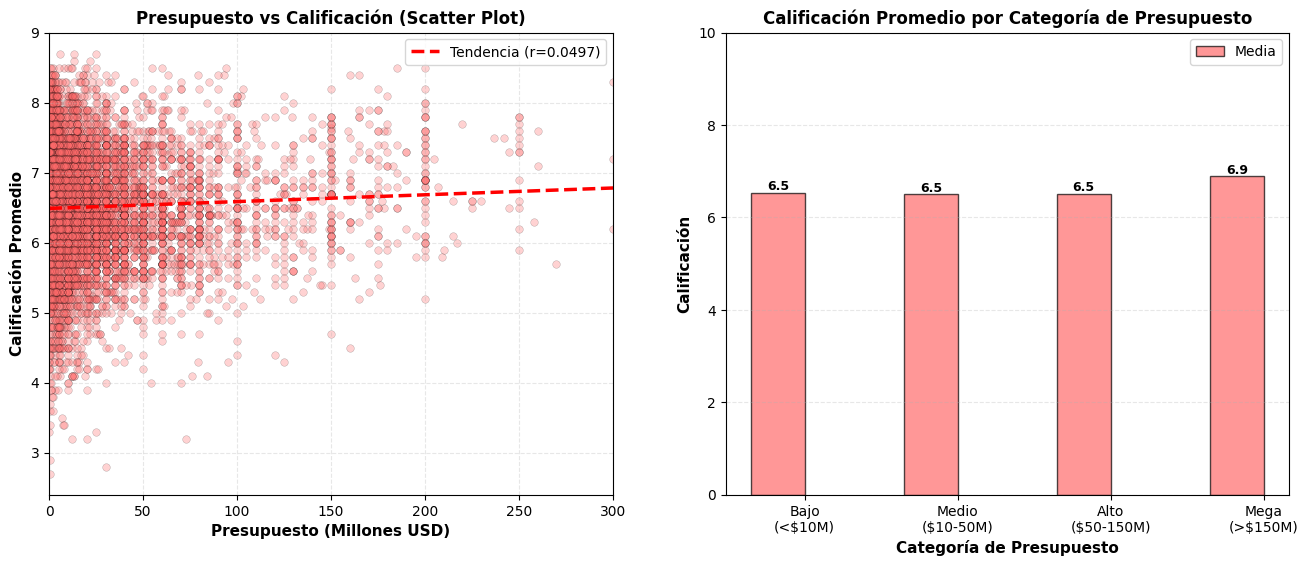

In [76]:
df_analisis = df[(df['budget'] > 0) & (df['voteAvg'] > 0) & (df['voteCount'] > 10)].copy()

corr, p_value = stats.pearsonr(df_analisis['budget'], df_analisis['voteAvg'])

print(f"\nCorrelación entre Presupuesto y Calificación Promedio:")
print(f"  Pearson r: {corr:.4f}")

df_analisis['categoria_presupuesto'] = pd.cut(df_analisis['budget'] / 1e6,
                                               bins=[0, 10, 50, 150, float('inf')],
                                               labels=['Bajo (<$10M)', 'Medio ($10-50M)', 
                                                      'Alto ($50-150M)', 'Mega (>$150M)'])

stats_presupuesto = df_analisis.groupby('categoria_presupuesto').agg({
    'voteAvg': ['mean', 'median', 'std', 'count'],
    'budget': 'mean',
    'voteCount': 'mean'
}).round(2)


print(f"\n{'Categoría':<20} {'Películas':<12} {'Presupuesto':<18} {'Calif. Media':<15} {'Calif. Mediana':<15}")
print("-"*90)

for categoria in ['Bajo (<$10M)', 'Medio ($10-50M)', 'Alto ($50-150M)', 'Mega (>$150M)']:
    if categoria in stats_presupuesto.index:
        row = stats_presupuesto.loc[categoria]
        print(f"{categoria:<20} {int(row[('voteAvg', 'count')]):<12} ${row[('budget', 'mean')]/1e6:<17.1f}M {row[('voteAvg', 'mean')]:<15.2f} {row[('voteAvg', 'median')]:<15.2f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(df_analisis['budget']/1e6, df_analisis['voteAvg'], alpha=0.3, s=30, color='#FF6B6B', edgecolor='black', linewidth=0.3)

z = np.polyfit(df_analisis['budget']/1e6, df_analisis['voteAvg'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(0, df_analisis['budget'].max()/1e6, 100)
ax1.plot(x_line, p_fit(x_line), "r--", linewidth=2.5, label=f'Tendencia (r={corr:.4f})')

ax1.set_xlabel('Presupuesto (Millones USD)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Calificación Promedio', fontweight='bold', fontsize=11)
ax1.set_title('Presupuesto vs Calificación (Scatter Plot)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
ax1.set_xlim(0, 300)

categorias_labels = ['Bajo\n(<$10M)', 'Medio\n($10-50M)', 'Alto\n($50-150M)', 'Mega\n(>$150M)']
medias_calif = []
medianas_calif = []
desv_est = []

for categoria in ['Bajo (<$10M)', 'Medio ($10-50M)', 'Alto ($50-150M)', 'Mega (>$150M)']:
    if categoria in stats_presupuesto.index:
        medias_calif.append(stats_presupuesto.loc[categoria, ('voteAvg', 'mean')])
        medianas_calif.append(stats_presupuesto.loc[categoria, ('voteAvg', 'median')])
        desv_est.append(stats_presupuesto.loc[categoria, ('voteAvg', 'std')])

x_pos = np.arange(len(categorias_labels))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, medias_calif, width, label='Media', color='#FF6B6B', alpha=0.7, edgecolor='black')

ax2.set_xlabel('Categoría de Presupuesto', fontweight='bold', fontsize=11)
ax2.set_ylabel('Calificación', fontweight='bold', fontsize=11)
ax2.set_title('Calificación Promedio por Categoría de Presupuesto', fontweight='bold', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(categorias_labels)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 10)

for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')



plt.show()

6. ¿Qué meses del año tienen menos competencia (menos estrenos) pero mantienen buenos ingresos? ¿Existe un "ventana de oportunidad" desaprovechada?


Meses con BAJA competencia:
  • Enero: 368 estrenos
  • Febrero: 366 estrenos
  • Abril: 358 estrenos
  • Mayo: 371 estrenos

Meses con ALTOS ingresos:
  • Mayo: $165.3M promedio
  • Junio: $165.8M promedio
  • Julio: $132.8M promedio
  • Noviembre: $127.8M promedio

VENTANAS DE OPORTUNIDAD (Baja competencia + Altos ingresos):
  • Abril: 358 estrenos, $102.3M ingresos
  • Mayo: 371 estrenos, $165.3M ingresos


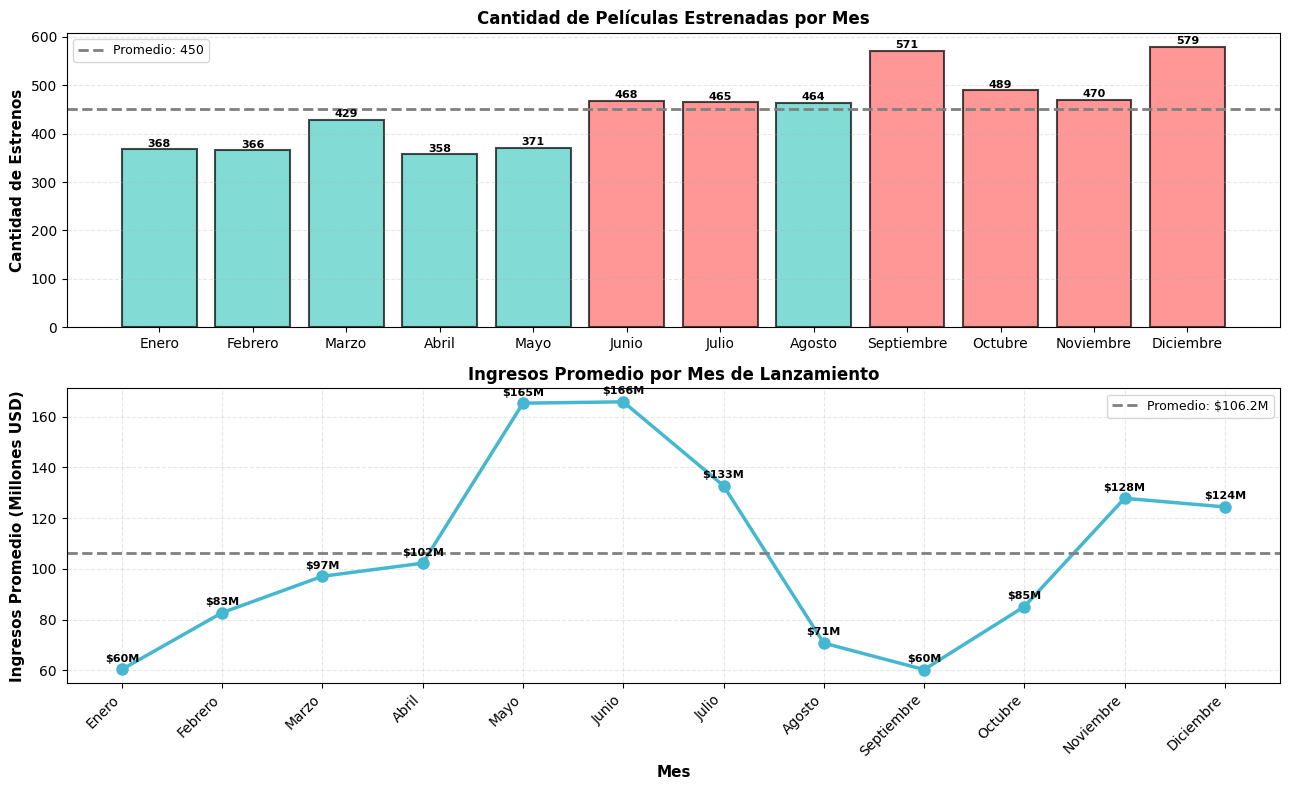

In [79]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['month'] = df['releaseDate'].dt.month

df_valido = df[(df['month'].notna()) & (df['revenue'] > 0)].copy()

estrenos_por_mes = df_valido.groupby('month').agg({
    'id': 'count',
    'revenue': 'mean'
}).reset_index()

estrenos_por_mes.columns = ['month', 'cantidad_estrenos', 'ingresos_promedio']

nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
estrenos_por_mes['mes_nombre'] = estrenos_por_mes['month'].apply(lambda x: nombres_meses[int(x)-1])

meses_bajos = estrenos_por_mes[estrenos_por_mes['cantidad_estrenos'] < estrenos_por_mes['cantidad_estrenos'].quantile(0.33)]
meses_altos_ingresos = estrenos_por_mes[estrenos_por_mes['ingresos_promedio'] > estrenos_por_mes['ingresos_promedio'].quantile(0.67)]

print(f"\nMeses con BAJA competencia:")
for _, row in meses_bajos.iterrows():
    print(f"  • {row['mes_nombre']}: {int(row['cantidad_estrenos'])} estrenos")

print(f"\nMeses con ALTOS ingresos:")
for _, row in meses_altos_ingresos.iterrows():
    print(f"  • {row['mes_nombre']}: ${row['ingresos_promedio']/1e6:.1f}M promedio")

oportunidad = estrenos_por_mes[
    (estrenos_por_mes['cantidad_estrenos'] < estrenos_por_mes['cantidad_estrenos'].median()) &
    (estrenos_por_mes['ingresos_promedio'] > estrenos_por_mes['ingresos_promedio'].median())
]

print(f"\nVENTANAS DE OPORTUNIDAD (Baja competencia + Altos ingresos):")
if len(oportunidad) > 0:
    for _, row in oportunidad.iterrows():
        print(f"  • {row['mes_nombre']}: {int(row['cantidad_estrenos'])} estrenos, ${row['ingresos_promedio']/1e6:.1f}M ingresos")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

colors_cantidad = ['#FF6B6B' if x > estrenos_por_mes['cantidad_estrenos'].median() else '#4ECDC4' 
                   for x in estrenos_por_mes['cantidad_estrenos']]

ax1.bar(estrenos_por_mes['mes_nombre'], estrenos_por_mes['cantidad_estrenos'], 
        color=colors_cantidad, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axhline(y=estrenos_por_mes['cantidad_estrenos'].mean(), color='gray', 
            linestyle='--', linewidth=2, label=f"Promedio: {estrenos_por_mes['cantidad_estrenos'].mean():.0f}")
ax1.set_ylabel('Cantidad de Estrenos', fontweight='bold', fontsize=11)
ax1.set_title('Cantidad de Películas Estrenadas por Mes', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend(fontsize=9)

for i, (mes, cant) in enumerate(zip(estrenos_por_mes['mes_nombre'], estrenos_por_mes['cantidad_estrenos'])):
    ax1.text(i, cant + 5, f'{int(cant)}', ha='center', fontweight='bold', fontsize=8)

ax2.plot(estrenos_por_mes['mes_nombre'], estrenos_por_mes['ingresos_promedio']/1e6, 
         marker='o', linewidth=2.5, markersize=8, color='#45B7D1')
ax2.axhline(y=estrenos_por_mes['ingresos_promedio'].mean()/1e6, color='gray', 
            linestyle='--', linewidth=2, label=f"Promedio: ${estrenos_por_mes['ingresos_promedio'].mean()/1e6:.1f}M")
ax2.set_ylabel('Ingresos Promedio (Millones USD)', fontweight='bold', fontsize=11)
ax2.set_xlabel('Mes', fontweight='bold', fontsize=11)
ax2.set_title('Ingresos Promedio por Mes de Lanzamiento', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(fontsize=9)

for i, (mes, ing) in enumerate(zip(estrenos_por_mes['mes_nombre'], estrenos_por_mes['ingresos_promedio']/1e6)):
    ax2.text(i, ing + 3, f'${ing:.0f}M', ha='center', fontweight='bold', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()